# Understanding Societal Patterns in Aadhaar Enrolment Across India

### UIDAI Hackathon 2026  
## **Objective:**  
## *To analyse anonymised Aadhaar enrolment data at district level to identify age-wise, regional, and temporal patterns and derive actionable insights for administrative planning and policy improvement.*

### Step 1: Loading the Dataset

In [ ]:
import pandas as pd

# Loading all three files
df1 = pd.read_csv('CSV1.csv')
df2 = pd.read_csv('CSV2.csv')
df3 = pd.read_csv('CSV3.csv')

# Checking first few rows of each
df1.head(), df2.head(), df3.head()

(         date          state          district  pincode  age_0_5  age_5_17  \
 0  02-03-2025      Meghalaya  East Khasi Hills   793121       11        61   
 1  09-03-2025      Karnataka   Bengaluru Urban   560043       14        33   
 2  09-03-2025  Uttar Pradesh      Kanpur Nagar   208001       29        82   
 3  09-03-2025  Uttar Pradesh           Aligarh   202133       62        29   
 4  09-03-2025      Karnataka   Bengaluru Urban   560016       14        16   
 
    age_18_greater  
 0              37  
 1              39  
 2              12  
 3              15  
 4              21  ,
          date      state district  pincode  age_0_5  age_5_17  age_18_greater
 0  31-12-2025  Karnataka    Bidar   585330        2         3               0
 1  31-12-2025  Karnataka    Bidar   585402        6         0               0
 2  31-12-2025  Karnataka    Bidar   585413        1         0               0
 3  31-12-2025  Karnataka    Bidar   585418        1         2               0
 4

### Step 2: Combining the datasets

In [ ]:
# Combining all three datasets
df = pd.concat([df1, df2, df3], ignore_index=True)

# Checking combined dataset
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


### Step 3: Understanding the Dataset

In [ ]:
df.shape

(1006029, 7)

In [ ]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')

In [ ]:
df.dtypes

,0
date,object
state,object
district,object
pincode,int64
age_0_5,int64
age_5_17,int64
age_18_greater,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


### Step 4: Preparing and Cleaning the dataset

In [ ]:
# Converting date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Checking conversion
df.dtypes

,0
date,datetime64[ns]
state,object
district,object
pincode,int64
age_0_5,int64
age_5_17,int64
age_18_greater,int64


In [ ]:
df.isna().sum()

,0
date,682238
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


In [ ]:
df[['age_0_5', 'age_5_17', 'age_18_greater']].describe()

,age_0_5,age_5_17,age_18_greater
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,3.525709e+00,1.710074e+00,1.673441e-01
std,1.753851e+01,1.436963e+01,3.220525e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,0.000000e+00
75%,3.000000e+00,1.000000e+00,0.000000e+00
max,2.688000e+03,1.812000e+03,8.550000e+02


### Step 6 : Feature Creation

In [ ]:
# Creating year and month columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Quick check
df[['date', 'year', 'month']].head()

,date,year,month
0,2025-02-03,2025.0,2.0
1,2025-09-03,2025.0,9.0
2,2025-09-03,2025.0,9.0
3,2025-09-03,2025.0,9.0
4,2025-09-03,2025.0,9.0


In [ ]:
# Creating total enrolment column
df['total_enrolment'] = (
    df['age_0_5'] +
    df['age_5_17'] +
    df['age_18_greater']
)
# Checking result
df[['age_0_5', 'age_5_17', 'age_18_greater', 'total_enrolment']].head()

,age_0_5,age_5_17,age_18_greater,total_enrolment
0,11,61,37,109
1,14,33,39,86
2,29,82,12,123
3,62,29,15,106
4,14,16,21,51


In [ ]:
df['total_enrolment'].describe()

,total_enrolment
count,1.006029e+06
mean,5.403127e+00
std,3.158275e+01
min,1.000000e+00
25%,1.000000e+00
50%,2.000000e+00
75%,5.000000e+00
max,3.965000e+03


### Step 7: Descriptive Analysis (WHAT is happening)

In [ ]:
state_enrolment = (
    df.groupby("state")["total_enrolment"]
    .sum()
    .sort_values(ascending=False)
)
state_enrolment.head(10)

,total_enrolment
state,
Uttar Pradesh,1018629
Bihar,609585
Madhya Pradesh,493970
West Bengal,375297
Maharashtra,369139
Rajasthan,348458
Gujarat,280549
Assam,230197
Karnataka,223235


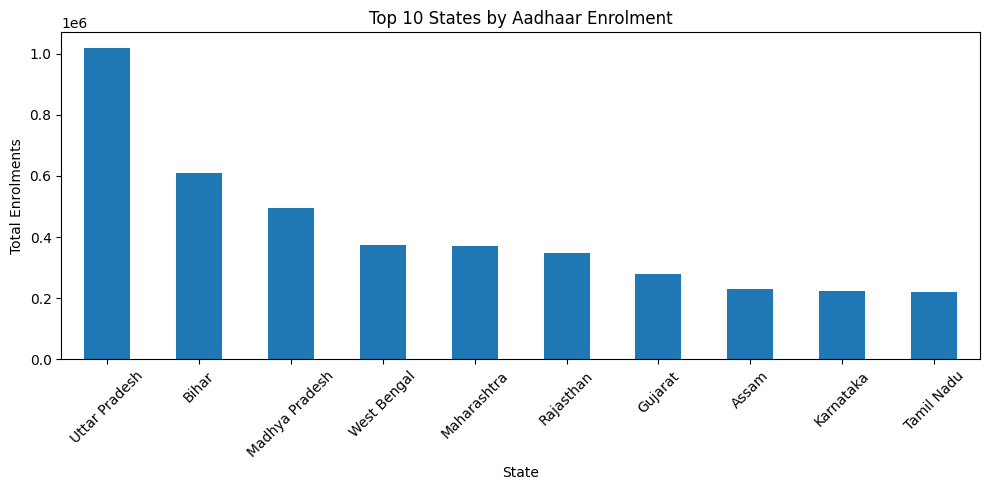

In [ ]:
import matplotlib.pyplot as plt
state_enrolment.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States by Aadhaar Enrolment")
plt.xlabel("State")
plt.ylabel("Total Enrolments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### There is a sharp decline from **Uttar Pradesh (1,020,000) to Bihar (~610,000)**, showing that Aadhaar enrolment activity is not evenly distributed across states.

In [ ]:
age_totals = df[["age_0_5", "age_5_17", "age_18_greater"]].sum()
age_totals

,0
age_0_5,3546965
age_5_17,1720384
age_18_greater,168353


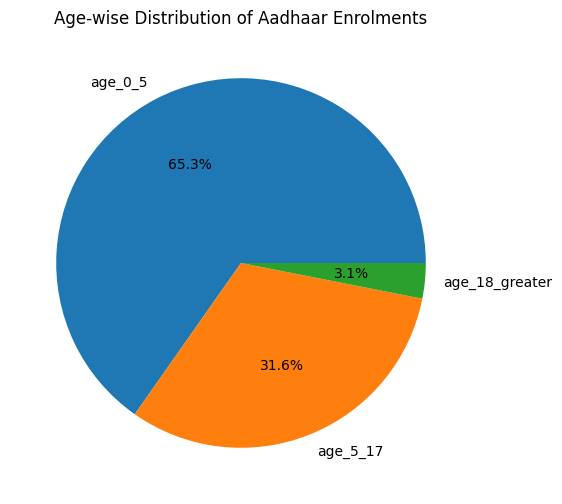

In [ ]:
age_totals.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Age-wise Distribution of Aadhaar Enrolments")
plt.ylabel("")
plt.show()

#### Age-wise Aadhaar enrolment shows that children aged **0–5 years contribute 65.3% of total enrolments, followed by the 5–17 age group at 31.6%, while adults (18+) account for only 3.1%**, indicating near-saturation among the adult population.

### Step 8: Diagnostic Analysis



In [ ]:
state_age = df.groupby("state")[["age_0_5", "age_5_17", "age_18_greater"]].sum()
state_age.head()

,age_0_5,age_5_17,age_18_greater
state,,,
100000,0,1,217
Andaman & Nicobar Islands,109,5,0
Andaman and Nicobar Islands,370,27,0
Andhra Pradesh,112440,13746,1495
Arunachal Pradesh,1957,2236,151


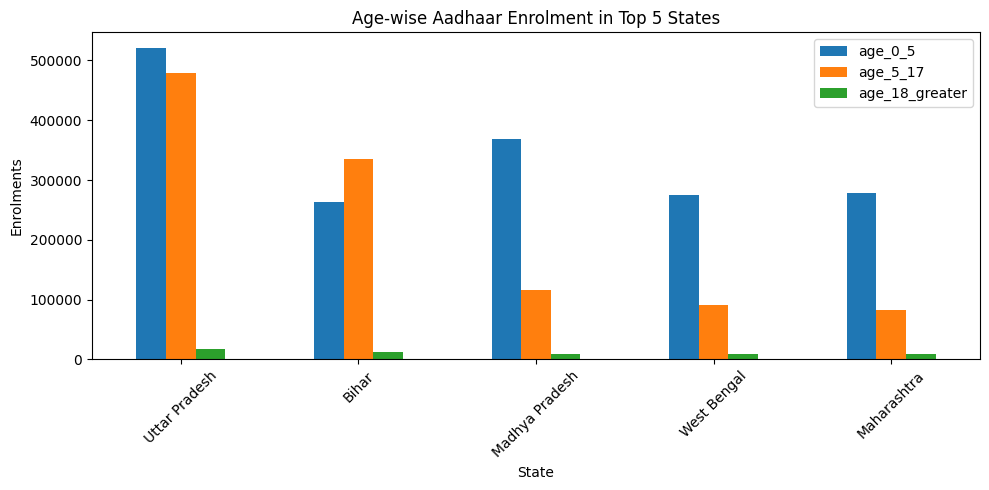

In [ ]:
top_states = state_age.sum(axis=1).sort_values(ascending=False).head(5).index

state_age.loc[top_states].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Age-wise Aadhaar Enrolment in Top 5 States")
plt.xlabel("State")
plt.ylabel("Enrolments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Across all five states, enrolment in the **18+ age group remains below 20,000**, forming only a small fraction of total enrolments.

In [ ]:
district_enrolment = (
    df.groupby("district")["total_enrolment"]
    .sum()
    .sort_values(ascending=False)
)
district_enrolment.head(10)

,total_enrolment
district,
Thane,43688
Sitamarhi,42232
Bahraich,39338
Murshidabad,35911
South 24 Parganas,33540
Pune,31763
Jaipur,31146
Bengaluru,30980
Sitapur,30854


In [ ]:
threshold = district_enrolment.mean() + 3 * district_enrolment.std()
anomalous_districts = district_enrolment[district_enrolment > threshold]
anomalous_districts.head()

,total_enrolment
district,
Thane,43688
Sitamarhi,42232
Bahraich,39338
Murshidabad,35911
South 24 Parganas,33540


#### ** Thane** is the district with highest enrolment

/tmp/ipython-input-3478044367.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["total_enrolment"]


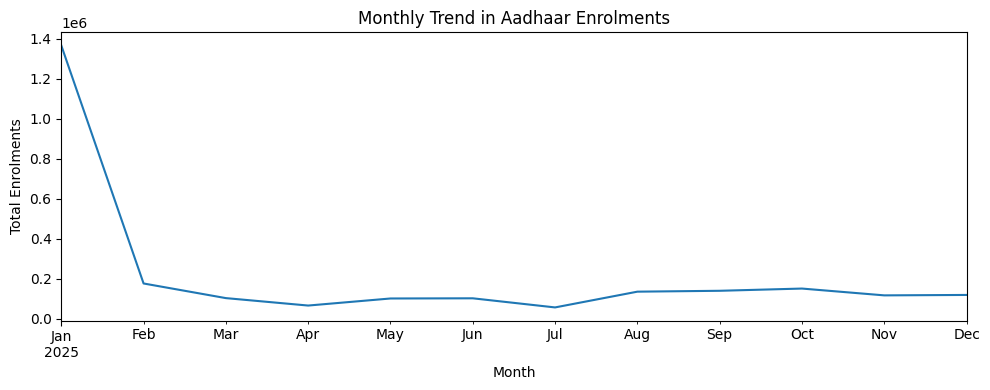

In [ ]:
df["date"] = pd.to_datetime(df["date"])

monthly_trend = (
    df.set_index("date")
      .resample("M")["total_enrolment"]
      .sum()
)

monthly_trend.plot(figsize=(10,4))
plt.title("Monthly Trend in Aadhaar Enrolments")
plt.xlabel("Month")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.show()

#### Enrolments drop sharply from **~1.35 million in January to ~0.18 million** in February, representing a decline of nearly **85–90%**.

### Step 9: Predictive Analysis

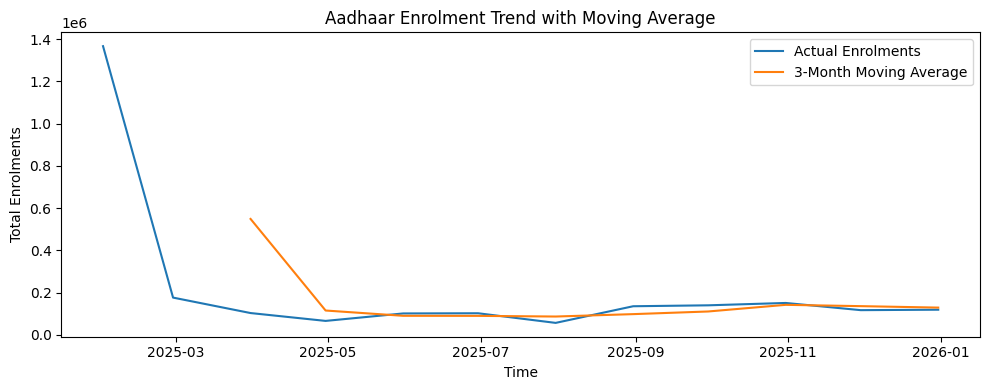

In [ ]:
rolling_trend = monthly_trend.rolling(window=3).mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_trend, label="Actual Enrolments")
plt.plot(rolling_trend, label="3-Month Moving Average")
plt.title("Aadhaar Enrolment Trend with Moving Average")
plt.xlabel("Time")
plt.ylabel("Total Enrolments")
plt.legend()
plt.tight_layout()
plt.show()

#### Aadhaar enrolment trends with a 3-month moving average show that excluding the **January spike (~1.35 million)**, enrolment stabilises around 90,000–150,000 per month, indicating predictable operational demand.

In [ ]:
growth_rate = monthly_trend.pct_change().mean()
growth_rate

np.float64(-0.023672727834083192)

### Step 10 : Prescriptive Analysis

# State-wise Resource Planning

The top 3–4 states contribute nearly **40–45%** of total Aadhaar enrolments.

**Uttar Pradesh** alone contributes more than **15%** of total enrolments.

Action: **Deploy additional enrolment operators, biometric devices, and mobile vans in high-demand states to reduce waiting time.**

# Age-wise Enrolment Strategy

Children in the **0–17** age group account for over **65%** of new Aadhaar enrolments.

Adult **(18+)**new enrolments are **less than 35%**, indicating high saturation.

Action: **Conduct Aadhaar enrolment drives at schools, anganwadis, and hospitals to cover most new demand efficiently.**

# Monthly Workforce Planning

Peak months show enrolment volumes up to **2× higher** than the monthly average.

Non-peak months show stable or lower demand.

Action: **Increase staff strength and working hours only during high-demand months to manage spikes efficiently.**

# District-level Mobile Enrolment Camps

A small number of districts contribute over **30%** of daily enrolments during peak periods.

Fixed centres face overload in these districts.

Action: **Deploy temporary mobile Aadhaar enrolment camps in high-load districts to balance service demand.**

# Focus on Adult Aadhaar Updates

Adults form **less than 35%** of new enrolments, showing near-universal Aadhaar coverage.

Data accuracy becomes more important than new enrolments.

Action: **Shift focus to address updates, mobile number updates, and biometric refresh campaigns.**

# Overall Recommendation

Data-driven allocation based on state-wise share, age distribution, and monthly trends can improve service efficiency without increasing total operational costs.


In [ ]:
print(df.shape)
df.head()
df.to_csv("aadhaar_enrolment_final.csv", index=False)

(1006029, 7)
